In [1]:
#Practicing statistics in python here ...

# Import numpy with alias np and pandas as pd
import numpy as np
import pandas as pd

insurance_df = pd.read_csv("Data/insurance.csv")
insurance_df.shape
insurance_df.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [2]:
# Subset sex for female: female
female_insur = insurance_df[insurance_df['sex'] == 'female']

# Calculate mean charges for females
print("Mean:", np.mean(female_insur['charges']))

# Calculate median charges for females
print("Median:", np.median(female_insur['charges']))

Mean: 12569.578843835347
Median: 9412.9625


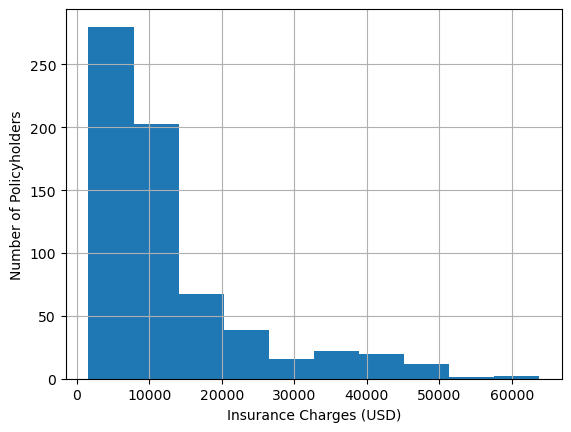

In [3]:
import matplotlib.pyplot as plt

# Subset for female
female_insur = insurance_df[insurance_df['sex'] == 'female']

# Histogram of charges for females
female_insur['charges'].hist()
plt.xlabel('Insurance Charges (USD)')
plt.ylabel('Number of Policyholders')
plt.show()

Analysis: the mean (12,569.58) is higher than ($9,412.96), indicating a right-skewed distribution. A small number of females with very high medical charges pull the mean upward, making the median a more reliable measure of the typical female policyholder's charges.


                 var           std
sex                               
female  1.238480e+08  11128.703801
male    1.682475e+08  12971.025915


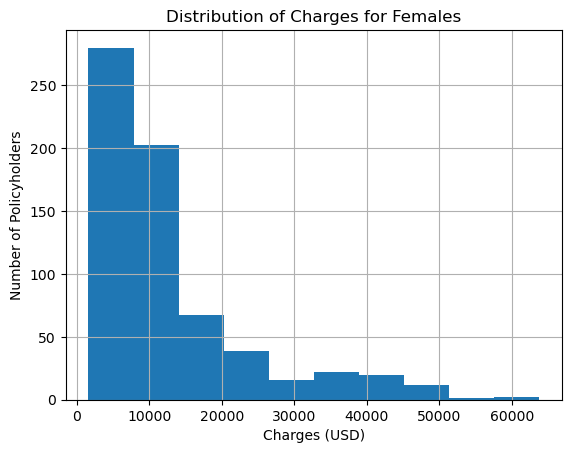

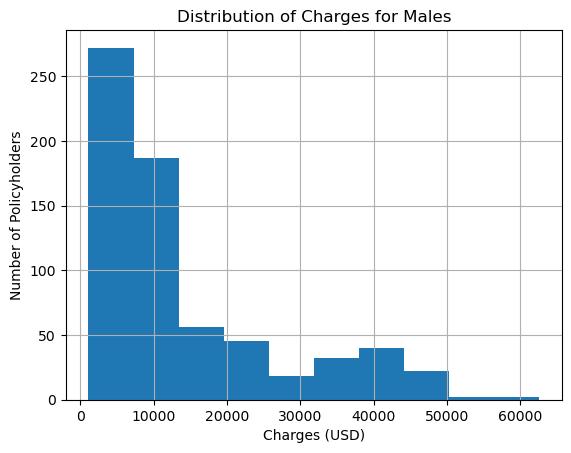

In [5]:
# Print variance and sd of charges for each sex
print(insurance_df.groupby('sex')['charges'].agg(['var', 'std']))

# Create histogram of charges for 'female'
insurance_df[insurance_df['sex'] == 'female']['charges'].hist()
plt.xlabel('Charges (USD)')
plt.ylabel('Number of Policyholders')
plt.title('Distribution of Charges for Females')
plt.show()

# Create histogram of charges for 'male'
plt.figure()
insurance_df[insurance_df['sex'] == 'male']['charges'].hist()
plt.xlabel('Charges (USD)')
plt.ylabel('Number of Policyholders')
plt.title('Distribution of Charges for Males')
plt.show()

In [8]:
print(np.quantile(insurance_df['charges'], [0, 0.25, 0.5, 0.75, 1]))
# Calculate the deciles of charges
print(np.quantile(insurance_df['charges'], [0, 0.1, 0.2, 0.3, 0.4, 0.5,0.6, 0.7,0.8, 0.9,1]))

[ 1121.8739    4740.28715   9382.033    16639.912515 63770.42801 ]
[ 1121.8739    2346.533615  3991.57572   5484.84677   7369.05273
  9382.033    11399.85716  13767.875345 20260.626406 34831.7197
 63770.42801 ]


In [16]:
# Calculate total charges per region: charges_by_region
churn_df = pd.read_csv('Data/telecom_churn.csv')
print(churn_df.columns.tolist())

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [19]:
# Calculate total MonthlyCharges per Contract type
charges_by_contract = churn_df.groupby('Contract')['MonthlyCharges'].sum()

# Compute the first and third quantiles and IQR
q1 = np.quantile(charges_by_contract, 0.25)
q3 = np.quantile(charges_by_contract, 0.75)
iqr = q3 - q1

# Calculate the lower and upper cutoffs for outliers
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

# Subset to find outliers
outliers = charges_by_contract[(charges_by_contract < lower) | (charges_by_contract > upper)]
print(outliers)
#No outliers found

Series([], Name: MonthlyCharges, dtype: float64)
